<a href="https://colab.research.google.com/github/likith1525/ExcelR-data-science-assignments/blob/main/Codes/12Random_Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **EDA**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the dataset directly from UCI Repository
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data"
column_names = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
df = pd.read_csv(url, names=column_names)

In [ ]:
# Remove ID as it is not a predictive feature
df = df.drop('Id', axis=1)

In [ ]:
# Basic Inspection
print("Dataset Shape:", df.shape)
print("\nMissing Values:\n", df.isnull().sum())
print("\nClass Distribution:\n", df['Type'].value_counts())
df.head()

Dataset Shape: (214, 10)

Missing Values:
 RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

Class Distribution:
 Type
2    76
1    70
7    29
3    17
5    13
6     9
Name: count, dtype: int64


,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


# Visualization

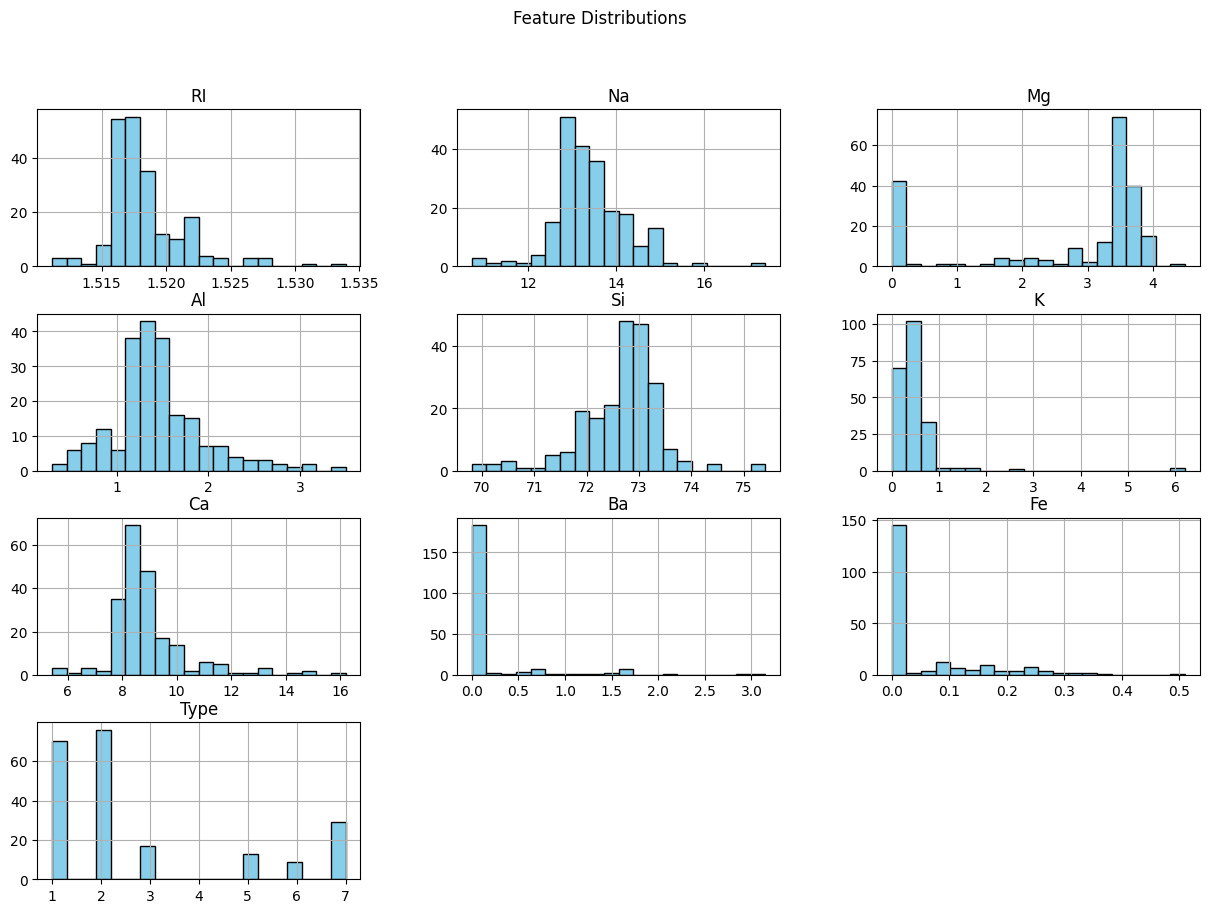

In [ ]:
# 1. Histograms for Distribution
df.hist(bins=20, figsize=(15, 10), color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions")
plt.show()

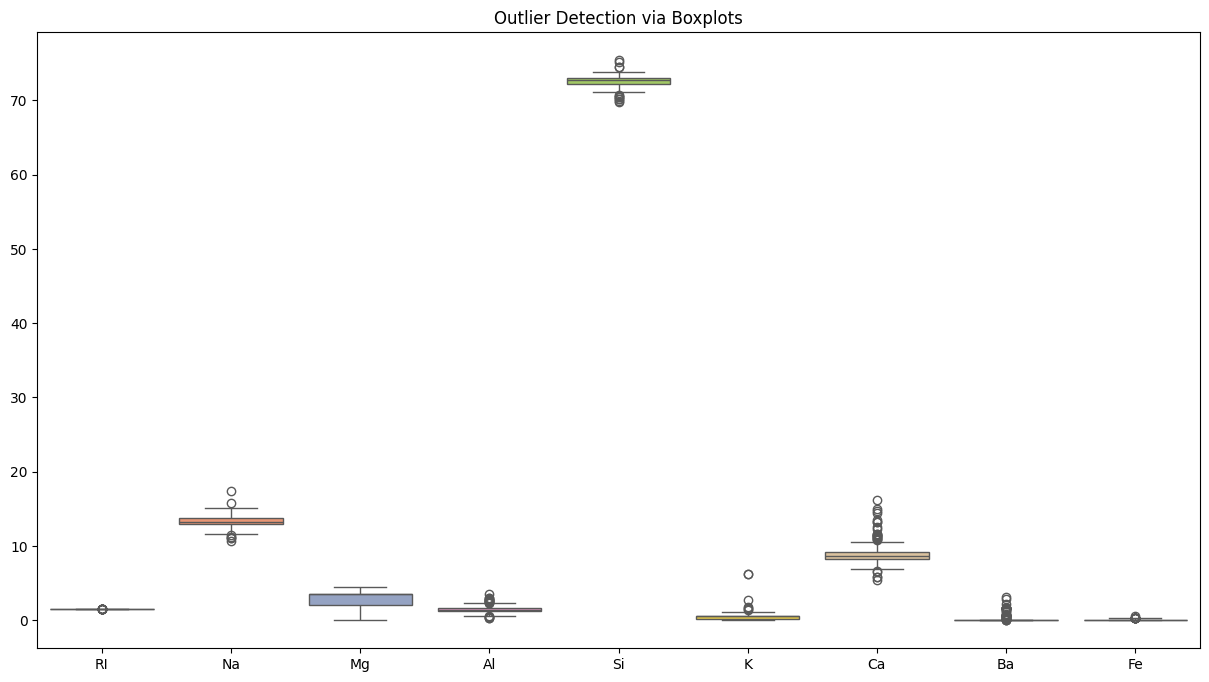

In [ ]:
# 2. Boxplots for Outlier Detection
plt.figure(figsize=(15, 8))
sns.boxplot(data=df.iloc[:, :-1], palette="Set2")
plt.title("Outlier Detection via Boxplots")
plt.show()

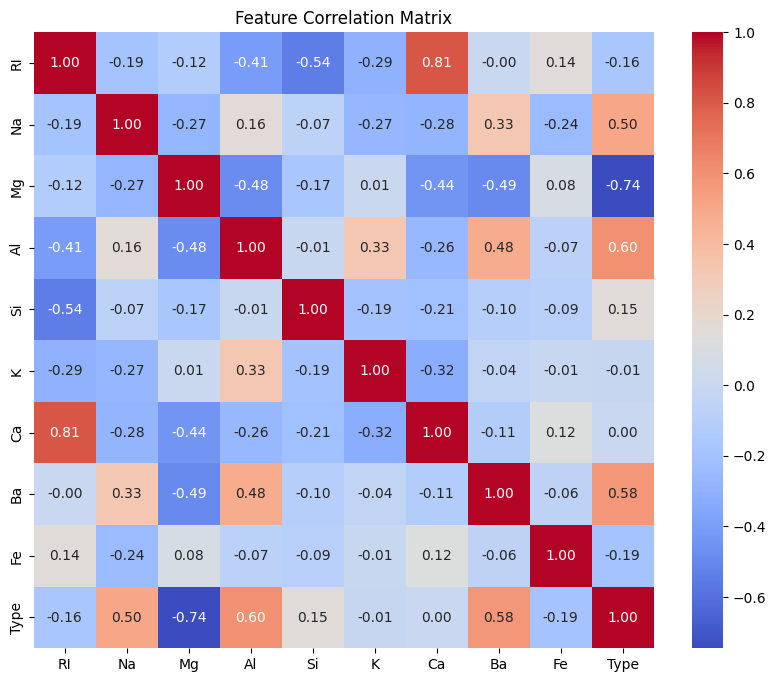

In [ ]:
# 3. Correlation Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Feature Correlation Matrix")
plt.show()

# patterns observed
*   **skewness:** Features like Ca and Ri are highly correlated
*   **outliers:** several features like K and Ba show significant outliers ,that may influence the model performance

#Data preprocessing

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# Split features and target
X = df.drop('Type', axis=1)
y = df['Type']

# 1. Handling Imbalance
# This creates synthetic samples for minority classes to balance the dataset.
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

# 2. Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# 3. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Balanced Dataset Shape: {X_res.shape}")

Balanced Dataset Shape: (456, 9)


# random forest implementation

--- Random Forest Performance ---
Accuracy: 0.93

Classification Report:
               precision    recall  f1-score   support

           1       0.88      0.82      0.85        17
           2       0.89      0.89      0.89        19
           3       0.82      0.90      0.86        10
           5       1.00      1.00      1.00        14
           6       1.00      1.00      1.00        14
           7       1.00      1.00      1.00        18

    accuracy                           0.93        92
   macro avg       0.93      0.94      0.93        92
weighted avg       0.94      0.93      0.93        92



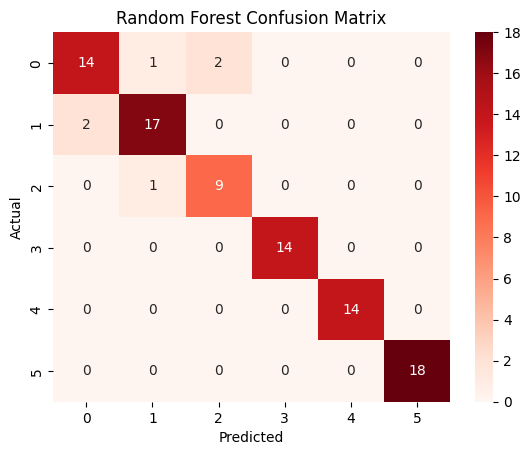

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Initialize and Train
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_scaled)

# Evaluation
print("--- Random Forest Performance ---")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf))

# Confusion Matrix Heatmap
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Reds')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Bagging and Boosting methods

In [ ]:
from sklearn.ensemble import BaggingClassifier, AdaBoostClassifier

# 1. Bagging Classifier
bag_model = BaggingClassifier(n_estimators=100, random_state=42)
bag_model.fit(X_train_scaled, y_train)
bag_acc = accuracy_score(y_test, bag_model.predict(X_test_scaled))

# 2. Boosting (AdaBoost)
boost_model = AdaBoostClassifier(n_estimators=100, random_state=42, algorithm='SAMME')
boost_model.fit(X_train_scaled, y_train)
boost_acc = accuracy_score(y_test, boost_model.predict(X_test_scaled))

# Comparison Table
results = pd.DataFrame({
    'Method': ['Random Forest', 'Bagging', 'Boosting (AdaBoost)'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), bag_acc, boost_acc]
})
print( results)

                Method  Accuracy
0        Random Forest  0.934783
1              Bagging  0.934783
2  Boosting (AdaBoost)  0.576087


#additional

In [ ]:
import pandas as pd

# 1. Comparison of Bagging and Boosting Methods
theory_data = {
    "Feature": [
        "Core Concept",
        "Model Relationship",
        "Primary Goal",
        "Sampling Technique",
        "Sensitivity to Outliers"
    ],
    "Bagging (Random Forest)": [
        "Parallel ensemble of independent models.",
        "Independent; built simultaneously.",
        "Reduce Variance (Overfitting).",
        "Bootstrap Aggregation (Random sampling with replacement).",
        "Robust to outliers and noise."
    ],
    "Boosting (AdaBoost/XGBoost)": [
        "Sequential ensemble of dependent models.",
        "Dependent; each model learns from previous errors.",
        "Reduce Bias (Underfitting).",
        "Weighted sampling; focus on misclassified samples.",
        "Sensitive to outliers as it tries to fix every error."
    ]
}

theory_df = pd.DataFrame(theory_data)

print("--- THEORY SUMMARY: BAGGING VS BOOSTING ---")
display(theory_df) # 'display' works specifically in Colab/Jupyter for pretty tables

--- THEORY SUMMARY: BAGGING VS BOOSTING ---


,Feature,Bagging (Random Forest),Boosting (AdaBoost/XGBoost)
0,Core Concept,Parallel ensemble of independent models.,Sequential ensemble of dependent models.
1,Model Relationship,Independent; built simultaneously.,Dependent; each model learns from previous err...
2,Primary Goal,Reduce Variance (Overfitting).,Reduce Bias (Underfitting).
3,Sampling Technique,Bootstrap Aggregation (Random sampling with re...,Weighted sampling; focus on misclassified samp...
4,Sensitivity to Outliers,Robust to outliers and noise.,Sensitive to outliers as it tries to fix every...


In [ ]:
# 2. Dataset Reference & Imbalance Handling Logic

def explain_imbalance_handling():
    """
    Prints the strategy used for the Glass dataset based on its specific attributes.
    """
    # Attribute list
    attributes = ["RI", "Na", "Mg", "Al", "Si", "K", "Ca", "Ba", "Fe"] #
    target = "Type (Class 1-7)" #


    print(f"Features: {', '.join(attributes)}") #
    print(f"Target: {target}\n") #

    print("--- HOW TO HANDLE IMBALANCE ---")
    print("1. SMOTE (Synthetic Minority Over-sampling Technique):")
    print("   - Strategy: Generates synthetic examples for minority classes (e.g., Type 3, 5, 6) rather than duplicating them.")
    print("   - Benefit: Prevents the model from being biased toward majority classes (Type 1 and 2).")

    print("\n2. Algorithmic Adjustment (Class Weights):")
    print("   - Implementation: RandomForestClassifier(class_weight='balanced')")
    print("   - Strategy: Penalizes the model more heavily for misclassifying minority class samples.")

    print("\n3. Evaluation Metrics:")
    print("   - Strategy: Prioritize F1-Score and Precision-Recall curves over simple Accuracy.")

explain_imbalance_handling()

Features: RI, Na, Mg, Al, Si, K, Ca, Ba, Fe
Target: Type (Class 1-7)

--- HOW TO HANDLE IMBALANCE ---
1. SMOTE (Synthetic Minority Over-sampling Technique):
   - Strategy: Generates synthetic examples for minority classes (e.g., Type 3, 5, 6) rather than duplicating them.
   - Benefit: Prevents the model from being biased toward majority classes (Type 1 and 2).

2. Algorithmic Adjustment (Class Weights):
   - Implementation: RandomForestClassifier(class_weight='balanced')
   - Strategy: Penalizes the model more heavily for misclassifying minority class samples.

3. Evaluation Metrics:
   - Strategy: Prioritize F1-Score and Precision-Recall curves over simple Accuracy.
